# Notebook 03 — Mô hình ARIMA

**Mục đích:** Xây dựng và đánh giá mô hình ARIMA dự báo PM2.5 tại Hà Nội.

**Quy trình:**
1. Kiểm định ADF (tính dừng).
2. Grid search chọn tham số (p, d, q) tốt nhất theo AIC.
3. Huấn luyện trên 2022–2024, dự báo rolling trên 2025.
4. Kiểm tra phần dư.
5. Đánh giá MAE, RMSE, R².

**Đầu vào:** `data/processed/clean_data.csv`  
**Đầu ra:** `results/arima_predictions.csv`


In [1]:
import sys
from pathlib import Path
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import pandas as pd
import matplotlib.pyplot as plt

from src.data_processor import load_clean, split_train_test
from src.arima_model import adf_test, select_arima_order, train_arima, forecast_arima, check_residuals
from src.evaluator import compute_metrics, naive_forecast
from src.visualizer import plot_forecast_vs_actual
from src.config import TARGET_COL

df = load_clean()
train, test = split_train_test(df)
print(f'Huấn luyện: {len(train)} ngày | Kiểm thử: {len(test)} ngày')

2026-08-05 20:47:43,864 [INFO] Tập huấn luyện: 1,084 ngày (2022-01-13 → 2024-12-31)
2026-08-05 20:47:43,865 [INFO] Tập kiểm thử:   181 ngày (2025-01-01 → 2025-06-30)


Huấn luyện: 1084 ngày | Kiểm thử: 181 ngày


## 1. Kiểm định ADF (Tính dừng)

In [2]:
adf_result = adf_test(train[TARGET_COL])
print('\n=== Kết quả kiểm định ADF ===')
for k, v in adf_result.items():
    print(f'  {k}: {v}')

if not adf_result['is_stationary']:
    print('\n→ Chuỗi KHÔNG dừng → cần sai phân (d=1). Kiểm tra lại sau sai phân:')
    adf_diff = adf_test(train[TARGET_COL].diff().dropna())
    for k, v in adf_diff.items():
        print(f'  (Sau d=1) {k}: {v}')

2026-08-05 20:47:43,902 [INFO] ADF Test: stat=-4.6077, p=0.0001 → DỪNG ✓



=== Kết quả kiểm định ADF ===
  ADF Statistic: -4.6077
  p-value: 0.0001
  Critical Values: {'1%': np.float64(-3.4365), '5%': np.float64(-2.8643), '10%': np.float64(-2.5682)}
  is_stationary: True


## 2. Grid search chọn tham số (p, d, q)

In [3]:
# Grid search — có thể mất vài phút
best_order = select_arima_order(
    train[TARGET_COL],
    p_range=range(0, 4),
    d_range=range(0, 2),
    q_range=range(0, 4),
    ic='aic'
)
print(f'\n✅ Bộ tham số tốt nhất: ARIMA{best_order}')

2026-08-05 20:47:43,921 [INFO] Grid search ARIMA(p,d,q) — tiêu chí: AIC...
2026-08-05 20:47:48,191 [INFO] Bộ tham số tốt nhất: ARIMA(3, 1, 1) — AIC=9376.38



✅ Bộ tham số tốt nhất: ARIMA(3, 1, 1)


## 3. Huấn luyện mô hình ARIMA

In [4]:
fit = train_arima(train[TARGET_COL], order=best_order)
print(fit.summary())

2026-08-05 20:47:48,209 [INFO] Huấn luyện ARIMA(3, 1, 1) trên 1084 quan sát...
2026-08-05 20:47:48,378 [INFO] ARIMA(3, 1, 1) — AIC=9376.38 | BIC=9401.31


                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                 1084
Model:                 ARIMA(3, 1, 1)   Log Likelihood               -4683.188
Date:                Wed, 05 Aug 2026   AIC                           9376.377
Time:                        20:47:48   BIC                           9401.314
Sample:                    01-13-2022   HQIC                          9385.818
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8425      0.021     39.674      0.000       0.801       0.884
ar.L2         -0.1880      0.025     -7.449      0.000      -0.237      -0.139
ar.L3          0.1079      0.025      4.368      0.0

## 4. Kiểm tra phần dư

2026-08-05 20:47:48,651 [INFO] Đã lưu biểu đồ phần dư: D:\DuAn\QuanLyBuiMinPM25\figures\07_arima_residuals.png


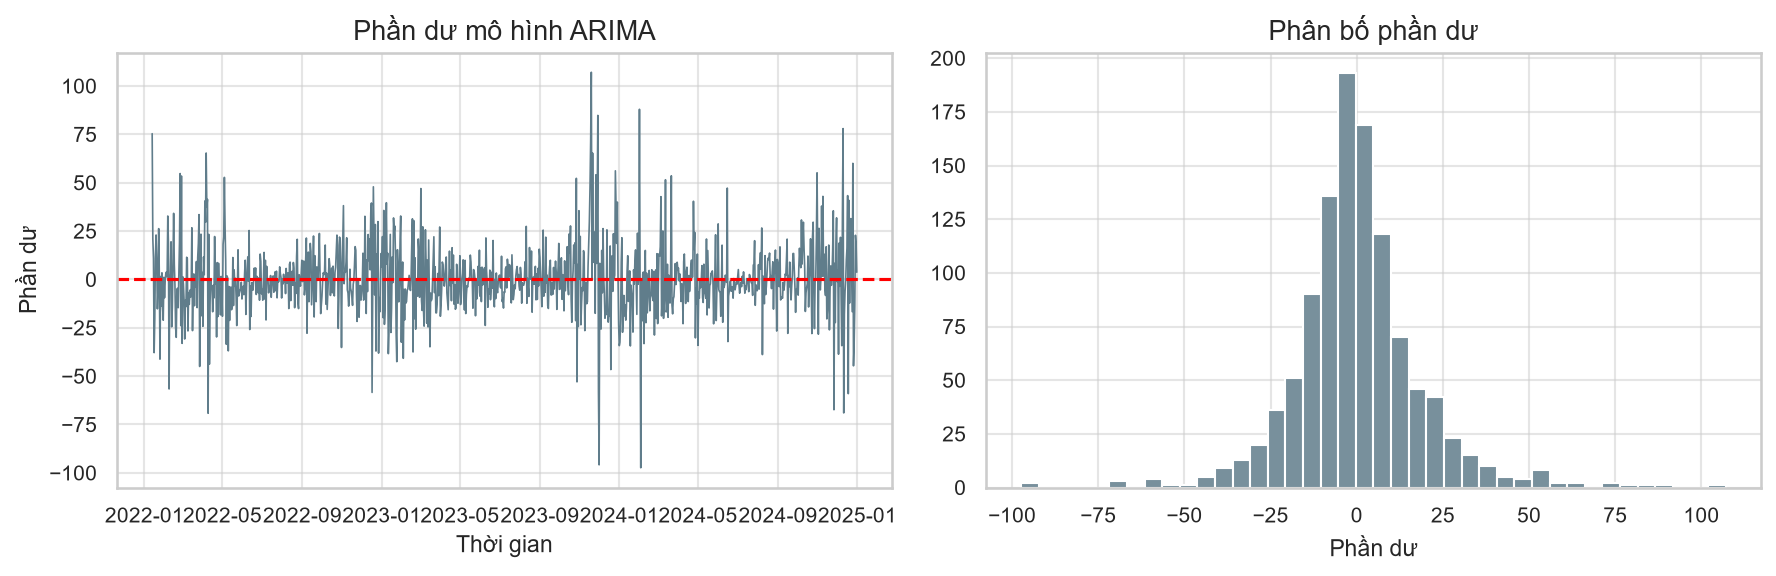

2026-08-05 20:47:48,819 [INFO] Kiểm định Ljung–Box (lag 1–10):
     lb_stat  lb_pvalue
1   0.023029   0.879382
2   0.033578   0.983351
3   0.126453   0.988484
4   0.346267   0.986635
5   0.913838   0.969212
6   1.647465   0.949105
7   3.021665   0.882991
8   3.800601   0.874651
9   5.931639   0.746740
10  8.174671   0.611780


,lb_stat,lb_pvalue
1,0.023029,0.879382
2,0.033578,0.983351
3,0.126453,0.988484
4,0.346267,0.986635
5,0.913838,0.969212
6,1.647465,0.949105
7,3.021665,0.882991
8,3.800601,0.874651
9,5.931639,0.746740
10,8.174671,0.611780



Nếu p-value > 0.05 ở các lag → phần dư không còn tự tương quan → mô hình đạt yêu cầu.


In [5]:
lb_result = check_residuals(fit, lags=10)
display(lb_result)
print('\nNếu p-value > 0.05 ở các lag → phần dư không còn tự tương quan → mô hình đạt yêu cầu.')

## 5. Dự báo rolling trên tập kiểm thử (2025)

In [6]:
# ⚠️ Lưu ý: Rolling forecast mất nhiều thời gian (1 vòng lặp / ngày)
arima_preds = forecast_arima(train[TARGET_COL], test[TARGET_COL], order=best_order)
print(f'\nSố ngày dự báo: {len(arima_preds)}')
print(arima_preds.head())

2026-08-05 20:47:48,850 [INFO] Bắt đầu dự báo rolling ARIMA(3, 1, 1) trên 181 ngày...
2026-08-05 20:47:49,018 [WARNING] Lỗi tại 2025-01-01 00:00:00: 'numpy.ndarray' object has no attribute 'iloc'. Dùng giá trị cuối.
2026-08-05 20:47:49,190 [WARNING] Lỗi tại 2025-01-02 00:00:00: 'numpy.ndarray' object has no attribute 'iloc'. Dùng giá trị cuối.
2026-08-05 20:47:49,354 [WARNING] Lỗi tại 2025-01-03 00:00:00: 'numpy.ndarray' object has no attribute 'iloc'. Dùng giá trị cuối.
2026-08-05 20:47:49,496 [WARNING] Lỗi tại 2025-01-04 00:00:00: 'numpy.ndarray' object has no attribute 'iloc'. Dùng giá trị cuối.
2026-08-05 20:47:49,671 [WARNING] Lỗi tại 2025-01-05 00:00:00: 'numpy.ndarray' object has no attribute 'iloc'. Dùng giá trị cuối.
2026-08-05 20:47:49,832 [WARNING] Lỗi tại 2025-01-06 00:00:00: 'numpy.ndarray' object has no attribute 'iloc'. Dùng giá trị cuối.
2026-08-05 20:47:50,006 [WARNING] Lỗi tại 2025-01-07 00:00:00: 'numpy.ndarray' object has no attribute 'iloc'. Dùng giá trị cuối.
2026


Số ngày dự báo: 181
date
2025-01-01     97.166250
2025-01-02    138.791667
2025-01-03    143.625000
2025-01-04    129.861250
2025-01-05    117.347083
Name: arima_pred, dtype: float64


## 6. Biểu đồ dự báo vs. thực tế

2026-08-05 20:48:19,218 [INFO] Đã lưu biểu đồ: D:\DuAn\QuanLyBuiMinPM25\figures\07_arima_forecast.png


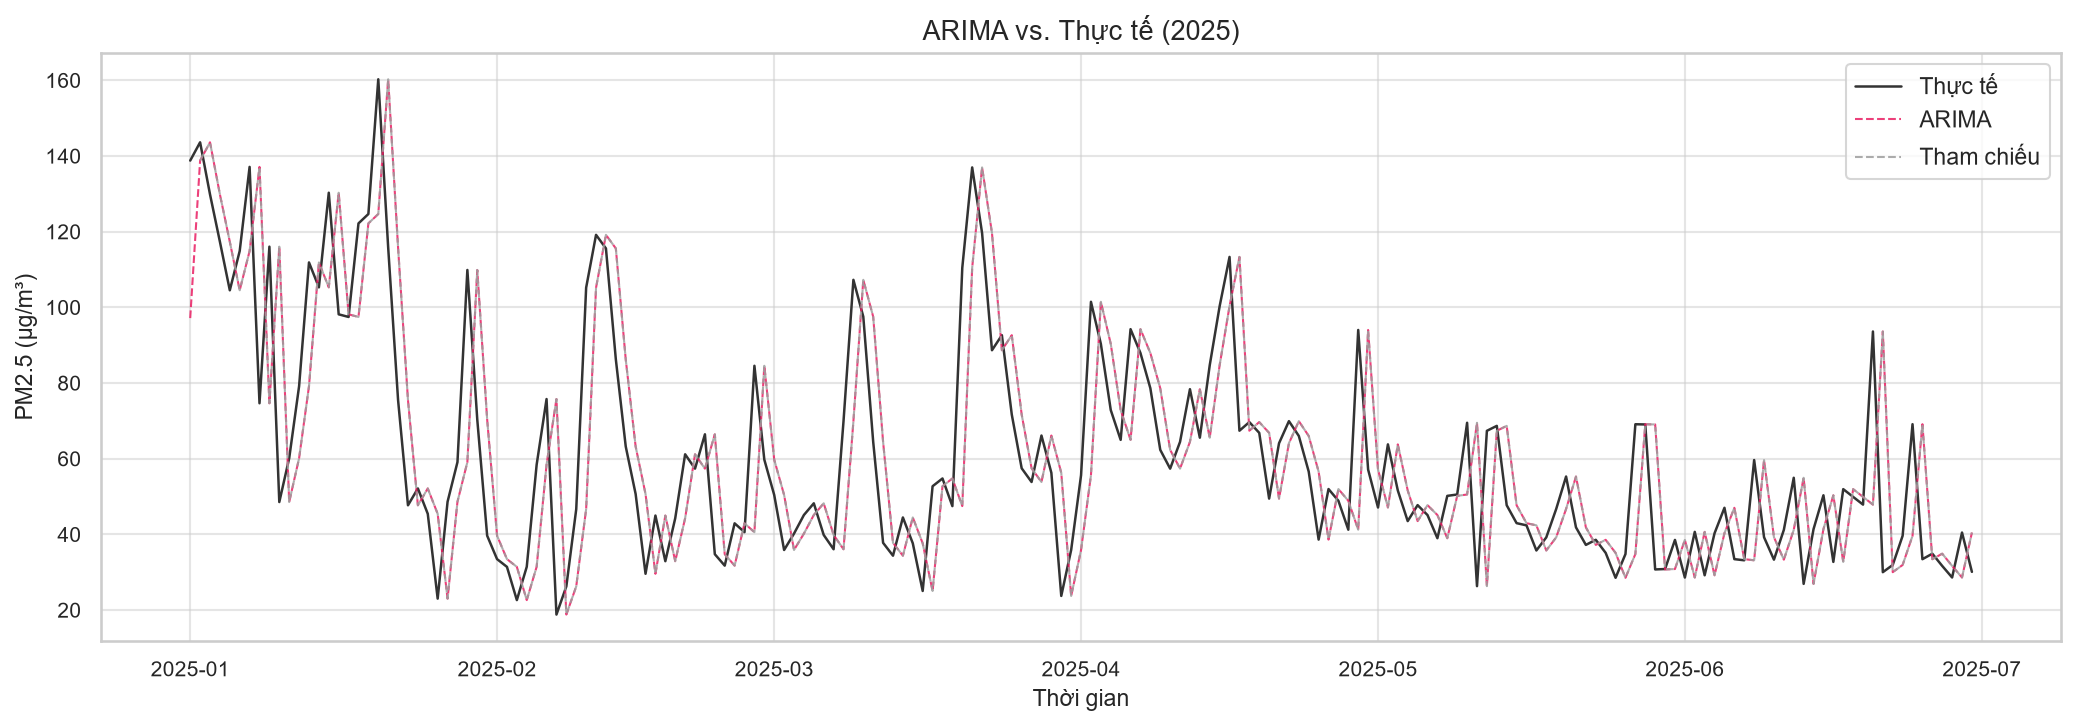

In [7]:
naive_preds = naive_forecast(test[TARGET_COL])

fig = plot_forecast_vs_actual(
    actual=test[TARGET_COL],
    preds={'ARIMA': arima_preds, 'Tham chiếu': naive_preds},
    title='ARIMA vs. Thực tế (2025)',
    filename='07_arima_forecast'
)
plt.show()

## 7. Đánh giá mô hình ARIMA

In [8]:
metrics_arima   = compute_metrics(test[TARGET_COL], arima_preds, model_name='ARIMA')
metrics_naive   = compute_metrics(test[TARGET_COL], naive_preds,  model_name='Dự báo tham chiếu')

import pandas as pd
result_df = pd.DataFrame([metrics_naive, metrics_arima]).set_index('Mô hình')
display(result_df)

improvement = (metrics_naive['RMSE'] - metrics_arima['RMSE']) / metrics_naive['RMSE'] * 100
print(f'\nARIMA cải thiện RMSE so với Tham chiếu: {improvement:.2f}%')

2026-08-05 20:48:19,372 [INFO] [ARIMA] MAE=16.9461 | RMSE=22.5466 | R²=0.4313
2026-08-05 20:48:19,375 [INFO] [Dự báo tham chiếu] MAE=16.8090 | RMSE=22.3952 | R²=0.4203


,MAE,RMSE,R²
Mô hình,,,
Dự báo tham chiếu,16.8090,22.3952,0.4203
ARIMA,16.9461,22.5466,0.4313



ARIMA cải thiện RMSE so với Tham chiếu: -0.68%


---
✅ **Hoàn thành!** Chạy tiếp `04_random_forest.ipynb`.